# Decoding the Attention Economy on Instagram
### A Data-Driven Analysis of Social Media Engagement

This project analyzes Instagram post analytics to understand how different
content characteristics influence engagement, reach, and follower growth.

In [18]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# SQL
import sqlite3

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Better looking plots
sns.set_style("whitegrid")

print("Libraries imported successfully")

Libraries imported successfully


In [19]:
from google.colab import files
uploaded = files.upload()

Saving Instagram_Post_Analytics.csv to Instagram_Post_Analytics.csv


In [20]:
df = pd.read_csv("Instagram_Post_Analytics.csv")

df.head()

,post_id,upload_date,media_type,likes,comments,shares,saves,reach,impressions,caption_length,hashtags_count,followers_gained,traffic_source,engagement_rate,content_category,share_rate,save_rate,engagement_score
0,IG0000001,25:23.0,Reel,31627,7559,4530,6393,615036,1007750,1340,3,899,Home Feed,4.97,Technology,0.007365,0.010395,85907
1,IG0000002,25:23.0,Photo,63206,3490,1680,6809,1237071,1345900,1351,20,805,Hashtags,5.59,Fitness,0.001358,0.005504,102462
2,IG0000003,25:23.0,Reel,94373,3727,1761,8367,1127470,1305369,242,24,758,Reels Feed,8.29,Beauty,0.001562,0.007421,140578
3,IG0000004,25:23.0,Reel,172053,7222,2875,9290,764030,897874,446,11,402,External,21.32,Music,0.003763,0.012159,232282
4,IG0000005,25:23.0,Video,99646,2703,4444,9746,7004,495406,1905,8,155,Profile,23.52,Technology,0.634495,1.391491,157368


In [21]:
df.shape

(29999, 18)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29999 entries, 0 to 29998
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   post_id           29999 non-null  object 
 1   upload_date       29999 non-null  object 
 2   media_type        29999 non-null  object 
 3   likes             29999 non-null  int64  
 4   comments          29999 non-null  int64  
 5   shares            29999 non-null  int64  
 6   saves             29999 non-null  int64  
 7   reach             29999 non-null  int64  
 8   impressions       29999 non-null  int64  
 9   caption_length    29999 non-null  int64  
 10  hashtags_count    29999 non-null  int64  
 11  followers_gained  29999 non-null  int64  
 12  traffic_source    29999 non-null  object 
 13  engagement_rate   29999 non-null  float64
 14  content_category  29999 non-null  object 
 15  share_rate        29999 non-null  float64
 16  save_rate         29999 non-null  float6

In [23]:
# Displays all column names in the dataset
df.columns

Index(['post_id', 'upload_date', 'media_type', 'likes', 'comments', 'shares',
       'saves', 'reach', 'impressions', 'caption_length', 'hashtags_count',
       'followers_gained', 'traffic_source', 'engagement_rate',
       'content_category', 'share_rate', 'save_rate', 'engagement_score'],
      dtype='object')

In [24]:
# Shows data types, non-null counts and memory usage
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29999 entries, 0 to 29998
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   post_id           29999 non-null  object 
 1   upload_date       29999 non-null  object 
 2   media_type        29999 non-null  object 
 3   likes             29999 non-null  int64  
 4   comments          29999 non-null  int64  
 5   shares            29999 non-null  int64  
 6   saves             29999 non-null  int64  
 7   reach             29999 non-null  int64  
 8   impressions       29999 non-null  int64  
 9   caption_length    29999 non-null  int64  
 10  hashtags_count    29999 non-null  int64  
 11  followers_gained  29999 non-null  int64  
 12  traffic_source    29999 non-null  object 
 13  engagement_rate   29999 non-null  float64
 14  content_category  29999 non-null  object 
 15  share_rate        29999 non-null  float64
 16  save_rate         29999 non-null  float6

In [8]:
# Shows mean, min, max, standard deviation etc.
# for numerical columns
df.describe()

,likes,comments,shares,saves,reach,impressions,caption_length,hashtags_count,followers_gained,engagement_rate,share_rate,save_rate,engagement_score
count,29999.000000,29999.000000,29999.000000,29999.000000,2.999900e+04,2.999900e+04,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000,29999.000000
mean,99912.661789,5017.781426,2502.912564,7490.124637,9.965616e+05,1.246669e+06,1103.110904,14.887430,502.152805,14.419276,0.011818,0.034557,147417.460882
std,57905.967401,2888.404881,1448.320395,4352.546949,5.777906e+05,5.970924e+05,635.991308,9.005811,290.364038,29.660210,0.212131,0.504959,60886.659466
min,7.000000,0.000000,0.000000,0.000000,1.650000e+02,5.107000e+03,0.000000,0.000000,0.000000,0.120000,0.000000,0.000000,8005.000000
25%,49755.000000,2530.500000,1246.000000,3690.500000,4.936810e+05,7.469585e+05,555.000000,7.000000,251.000000,5.180000,0.001253,0.003724,97332.000000
50%,99580.000000,5042.000000,2498.000000,7483.000000,9.921810e+05,1.241026e+06,1100.000000,15.000000,501.000000,9.190000,0.002507,0.007486,147132.000000
75%,150225.000000,7518.000000,3768.000000,11294.000000,1.494798e+06,1.749264e+06,1656.000000,23.000000,755.000000,15.670000,0.005010,0.015156,197401.000000
max,200000.000000,10000.000000,5000.000000,15000.000000,1.999865e+06,2.497940e+06,2200.000000,30.000000,1000.000000,3259.820000,29.193939,50.945455,288156.000000


In [25]:
# Counts missing values in each column
df.isnull().sum()


,0
post_id,0
upload_date,0
media_type,0
likes,0
comments,0
shares,0
saves,0
reach,0
impressions,0
caption_length,0


In [26]:
df.duplicated().sum()

np.int64(0)

In [28]:
df['engagement_score'] = df['likes'] + df['comments'] + df['shares'] + df['saves']

In [29]:
df[['likes','comments','shares','saves','engagement_score']].head()

,likes,comments,shares,saves,engagement_score
0,31627,7559,4530,6393,50109
1,63206,3490,1680,6809,75185
2,94373,3727,1761,8367,108228
3,172053,7222,2875,9290,191440
4,99646,2703,4444,9746,116539


In [30]:
df['engagement_efficiency'] = df['engagement_score'] / df['reach']

df[['engagement_score','reach','engagement_efficiency']].head()

,engagement_score,reach,engagement_efficiency
0,50109,615036,0.081473
1,75185,1237071,0.060777
2,108228,1127470,0.095992
3,191440,764030,0.250566
4,116539,7004,16.638921


In [31]:
df['reach_impression_ratio'] = df['reach'] / df['impressions']

df[['reach','impressions','reach_impression_ratio']].head()

,reach,impressions,reach_impression_ratio
0,615036,1007750,0.610306
1,1237071,1345900,0.919140
2,1127470,1305369,0.863717
3,764030,897874,0.850932
4,7004,495406,0.014138


In [32]:
threshold = df['engagement_rate'].quantile(0.90)
threshold

np.float64(28.77)

In [33]:
df['is_viral'] = df['engagement_rate'] >= threshold

df[['engagement_rate','is_viral']].head()

,engagement_rate,is_viral
0,4.97,False
1,5.59,False
2,8.29,False
3,21.32,False
4,23.52,False


In [34]:
df.groupby('media_type')['engagement_rate'].mean().sort_values(ascending=False)

,engagement_rate
media_type,
Video,14.619641
Reel,14.540539
Carousel,14.323362
Photo,14.191059


In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

# Better visual style
sns.set_theme(style="whitegrid")

# Bigger readable plots
plt.rcParams['figure.figsize'] = (10,6)

# Larger fonts for readability
plt.rcParams['font.size'] = 12

print("Visualization style applied")

Visualization style applied


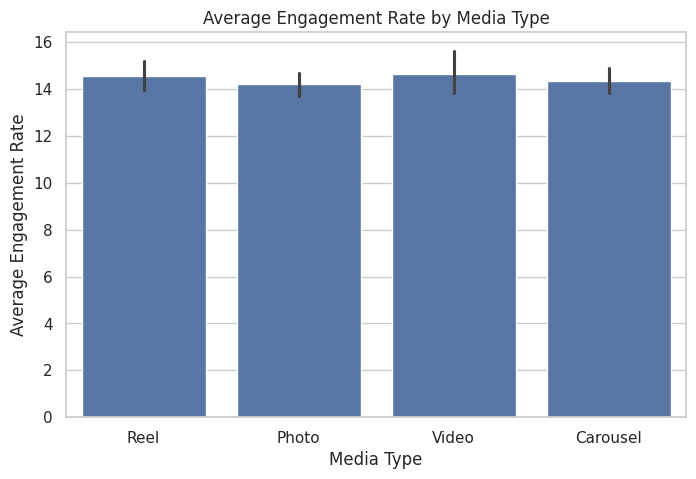

In [38]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='media_type',
    y='engagement_rate',
    data=df,
    estimator=np.mean
)

plt.title("Average Engagement Rate by Media Type")
plt.xlabel("Media Type")
plt.ylabel("Average Engagement Rate")

plt.show()

Insights (Average Engagement Rate by Media Type)

Video posts have the highest average engagement rate, making them the most effective format.

Reels also perform well, with engagement close to videos.

Carousel posts show moderate engagement, slightly lower than videos and reels.

Photo posts have the lowest engagement rate among the media types.

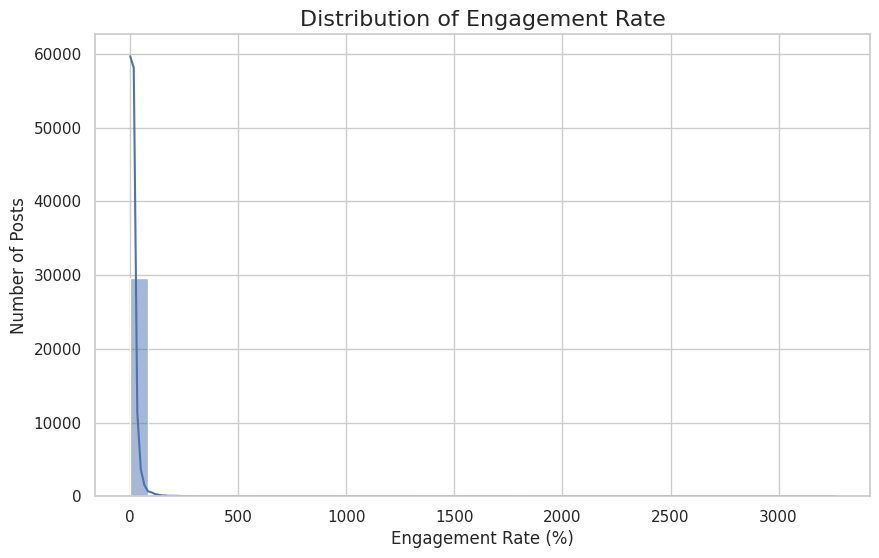

In [40]:
plt.figure()

sns.histplot(
    df['engagement_rate'],
    bins=40,
    kde=True,
    color='#4C72B0'
)

plt.title("Distribution of Engagement Rate", fontsize=16)
plt.xlabel("Engagement Rate (%)")
plt.ylabel("Number of Posts")

plt.show()

Insights (Distribution of Engagement Rate)

Most posts have low to moderate engagement rates, clustered near the beginning of the graph.

The distribution is right-skewed, meaning only a few posts achieve extremely high engagement.

A small number of posts show very high engagement, indicating viral content.

This suggests that most posts perform normally while only a few become highly popular.

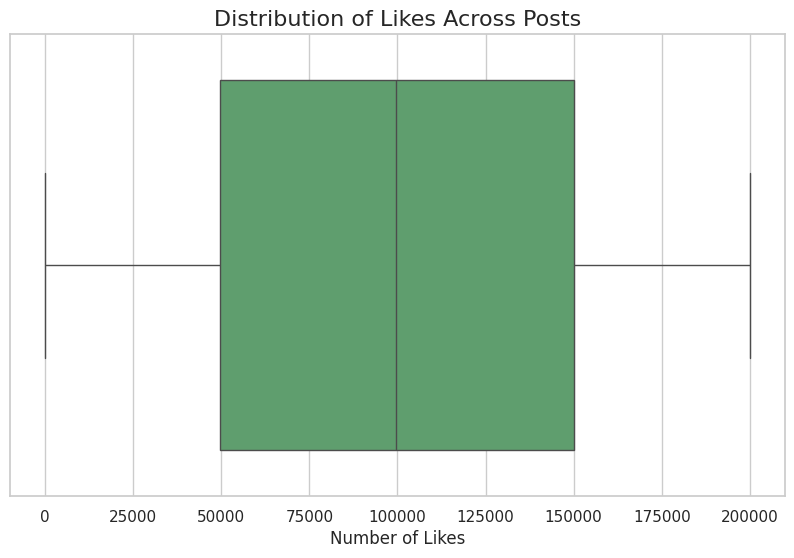

In [41]:
plt.figure()

sns.boxplot(
    x=df['likes'],
    color='#55A868'
)

plt.title("Distribution of Likes Across Posts", fontsize=16)
plt.xlabel("Number of Likes")

plt.show()

Insights (Distribution of Likes Across Posts)

The median number of likes is around the middle of the box, showing a typical engagement level for most posts.

Likes vary widely, indicating different levels of popularity among posts.

The long range of the box and whiskers shows that some posts receive significantly more likes than others.

This suggests that a few posts become very popular while most receive moderate likes.

/tmp/ipykernel_606/2298602779.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


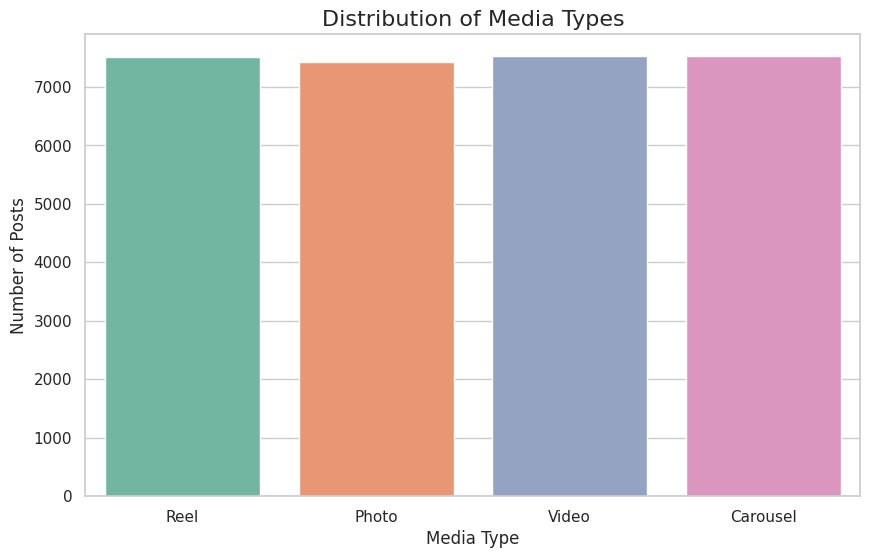

In [42]:
plt.figure()

sns.countplot(
    x='media_type',
    data=df,
    palette='Set2'
)

plt.title("Distribution of Media Types", fontsize=16)
plt.xlabel("Media Type")
plt.ylabel("Number of Posts")

plt.show()

Insights (Distribution of Media Types)

All media types (Reel, Photo, Video, Carousel) appear in almost equal numbers.

No single content format dominates the dataset.

This balanced distribution allows fair comparison of engagement across media types.

It suggests that creators use different content formats equally on the platform.

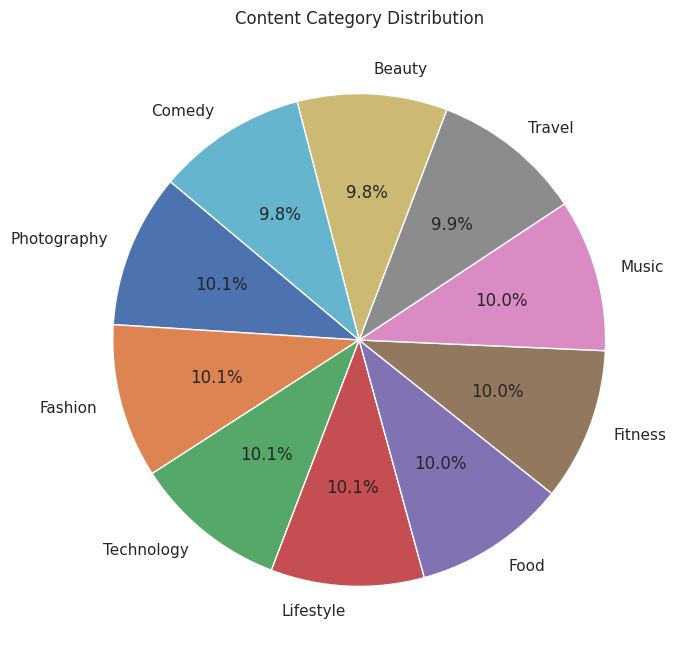

In [43]:
category_counts = df['content_category'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    category_counts,
    labels=category_counts.index,
    autopct='%1.1f%%',
    startangle=140
)

plt.title("Content Category Distribution")

plt.show()

The dataset contains a balanced representation of content categories, with each niche contributing approximately 10% of the total posts. This balanced distribution ensures that engagement comparisons across categories are not biased by dataset imbalance.![image.png](Insights (Content Category Distribution)

All content categories appear in almost equal proportions (around 10%).

No single category dominates the dataset.

This balanced distribution allows fair comparison of engagement across different niches.

It shows that the dataset includes a wide variety of Instagram content topics.)

/tmp/ipykernel_606/3227941411.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


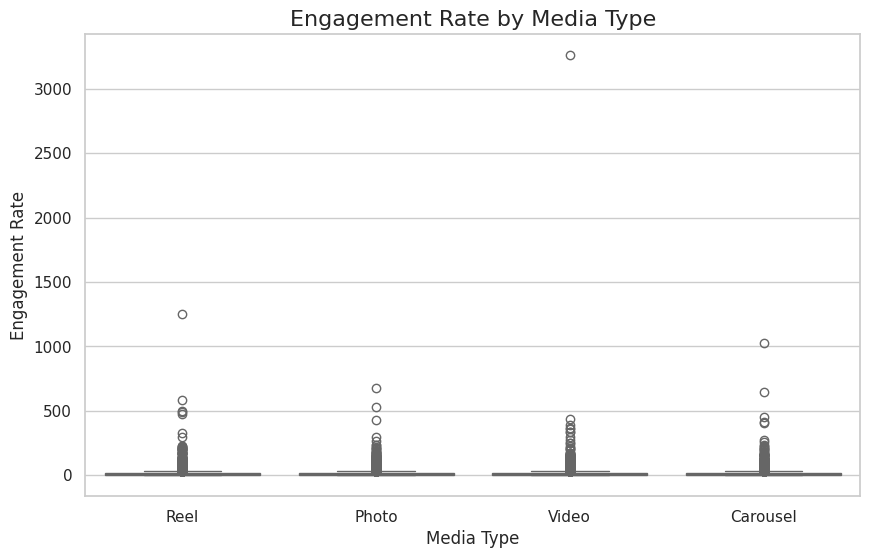

In [44]:
plt.figure()

sns.boxplot(
    x='media_type',
    y='engagement_rate',
    data=df,
    palette='coolwarm'
)

plt.title("Engagement Rate by Media Type", fontsize=16)
plt.xlabel("Media Type")
plt.ylabel("Engagement Rate")

plt.show()

Engagement is fairly consistent across Reels, Photos, Videos, and Carousels.
Some posts perform extremely well while many perform normally.
Viral posts

The box plot reveals that engagement rates are relatively consistent across different media types. However, all formats exhibit significant variability with several extreme outliers, indicating the presence of highly viral posts that receive unusually high engagement compared to typical posts.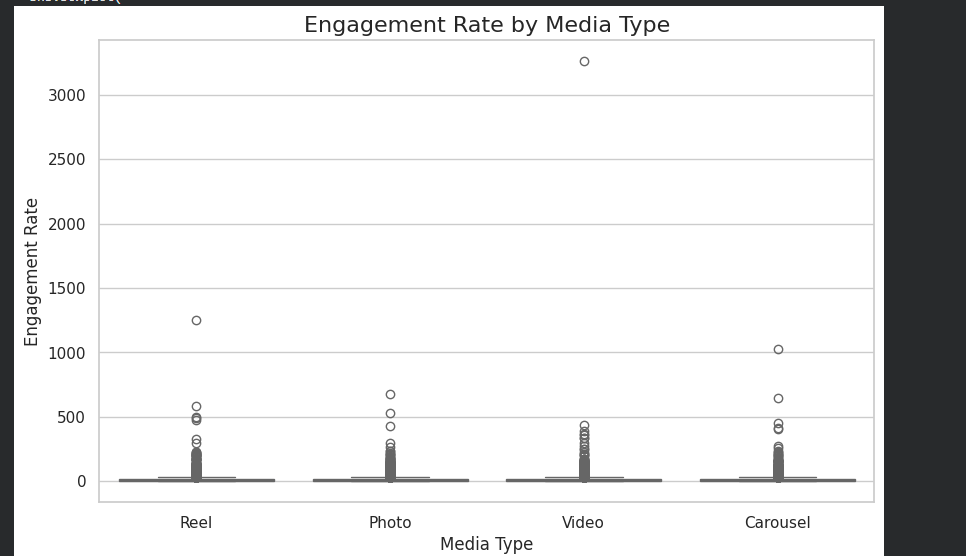

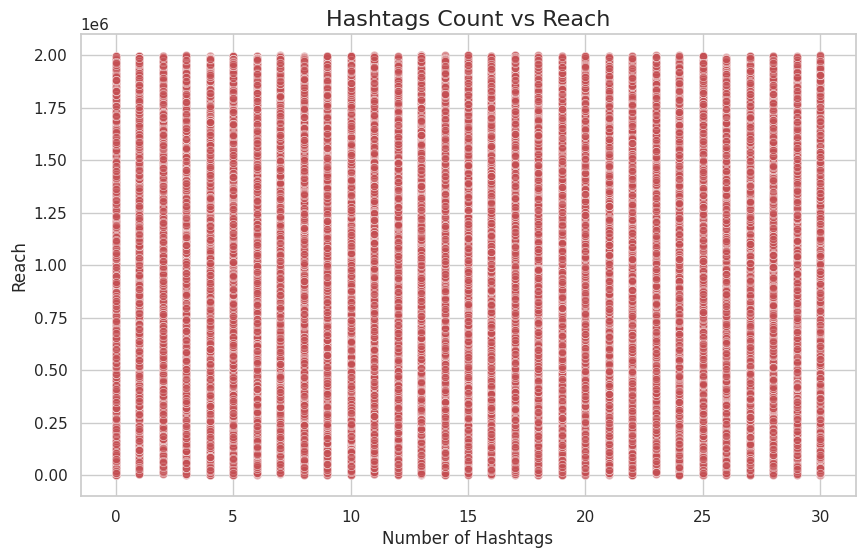

In [45]:
plt.figure()

sns.scatterplot(
    x='hashtags_count',
    y='reach',
    data=df,
    color='#C44E52',
    alpha=0.6
)

plt.title("Hashtags Count vs Reach", fontsize=16)
plt.xlabel("Number of Hashtags")
plt.ylabel("Reach")

plt.show()

Insights (Hashtags Count vs Reach)

The points are widely scattered, showing no clear relationship between hashtag count and reach.

Posts with both few and many hashtags can achieve high reach.

Increasing the number of hashtags does not guarantee higher visibility.

This suggests that content quality or algorithm exposure may influence reach more than hashtags.

Engagement by Content **Category**

/tmp/ipykernel_606/1577549969.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


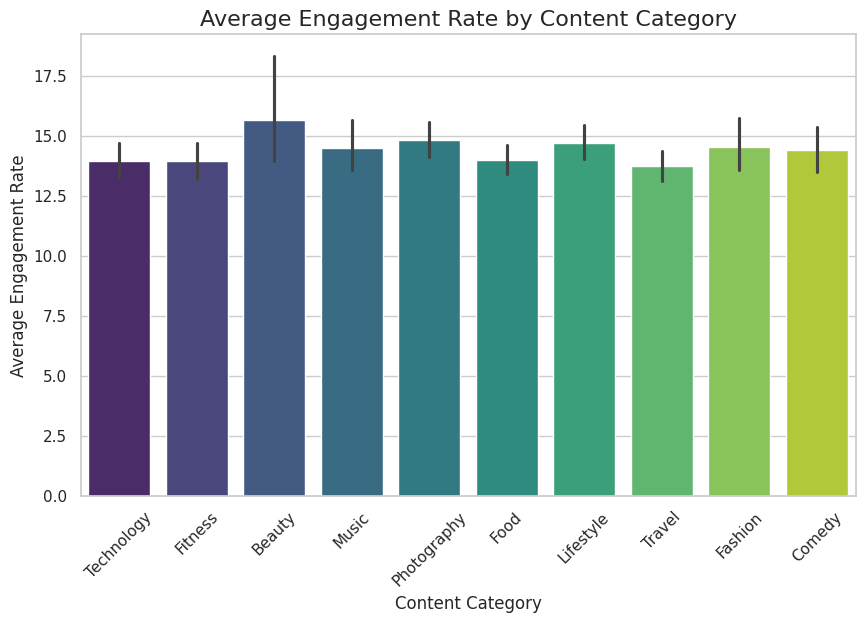

In [46]:
plt.figure()

sns.barplot(
    x='content_category',
    y='engagement_rate',
    data=df,
    palette='viridis'
)

plt.title("Average Engagement Rate by Content Category", fontsize=16)
plt.xlabel("Content Category")
plt.ylabel("Average Engagement Rate")

plt.xticks(rotation=45)

plt.show()

Beauty-related posts achieve the highest average engagement rate among all categories, suggesting that visually appealing and lifestyle-driven content resonates strongly with Instagram audiences. Travel content, while still performing well, shows slightly lower engagement compared to other niches.![image.png](Insights (Average Engagement Rate by Content Category)

Beauty content shows the highest average engagement rate among all categories.

Categories like Photography, Lifestyle, and Fashion also perform relatively well.

Travel content shows slightly lower engagement compared to other niches.

Overall differences between categories are not very large, suggesting most content types receive similar engagement levels.

Media Type + Category Heatmap

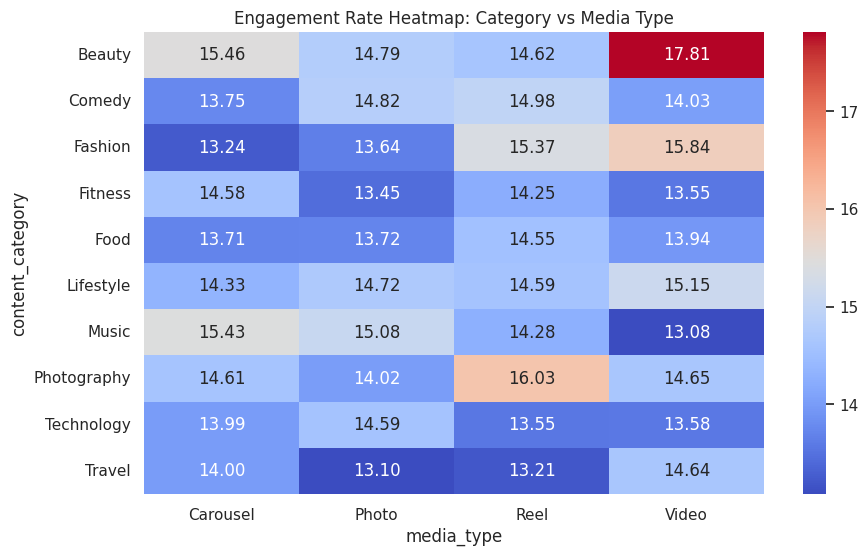

In [47]:
pivot_table = df.pivot_table(
    values='engagement_rate',
    index='content_category',
    columns='media_type',
    aggfunc='mean'
)

plt.figure(figsize=(10,6))

sns.heatmap(
    pivot_table,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Engagement Rate Heatmap: Category vs Media Type")

plt.show()

Insights (Engagement Rate Heatmap: Category vs Media Type)

Beauty videos have the highest engagement rate, making this the best-performing content combination.

Photography reels also show strong engagement, indicating short-form visual content performs well.

Some combinations like Travel photos and Music videos show relatively lower engagement.

The heatmap shows that engagement depends on both content category and media format, not just one factor.

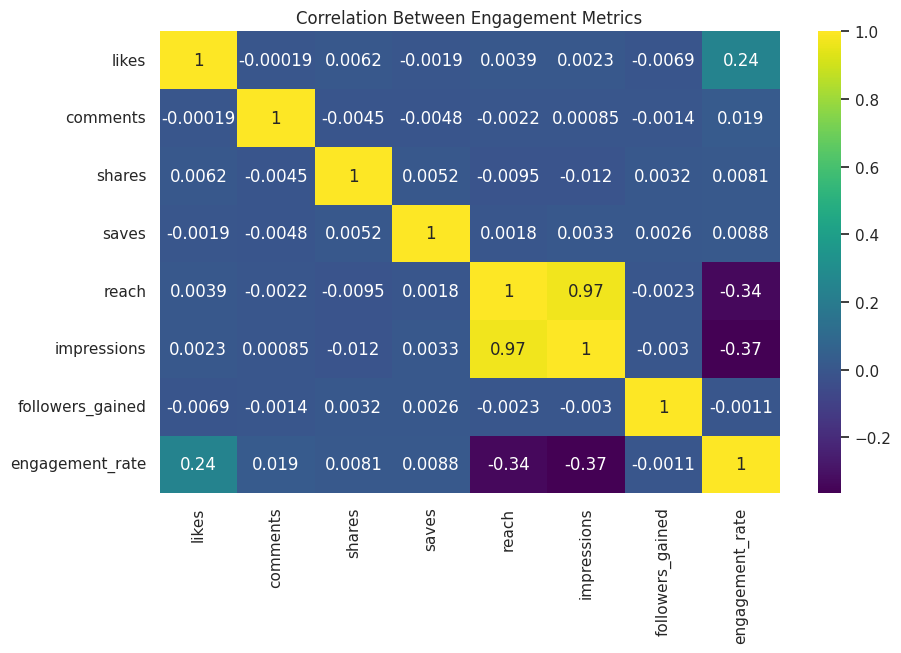

In [48]:
plt.figure(figsize=(10,6))

numeric_cols = df[['likes','comments','shares','saves','reach','impressions','followers_gained','engagement_rate']]

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap='viridis'
)

plt.title("Correlation Between Engagement Metrics")

plt.show()

Insights (Correlation Between Engagement Metrics)

Reach and impressions have a very strong positive correlation (0.97), meaning posts that reach more users also get more views.

Likes show the strongest positive relationship with engagement rate compared to other interactions.

Engagement rate has a slight negative correlation with reach and impressions, suggesting larger audiences may lower engagement percentage.

Comments, shares, and saves show very weak correlations, indicating they contribute less strongly to overall engagement patterns.

general conclusion


Video-based content generally performs better in terms of engagement compared to other media formats.

Beauty-related content receives the highest engagement, while categories like travel tend to show slightly lower engagement.

The combination of Beauty content and Video format produces the highest engagement, showing that both content type and format influence performance.

The number of hashtags does not show a strong relationship with reach, indicating that simply adding more hashtags does not guarantee higher visibility.

Most posts receive moderate engagement, while only a small number of posts achieve extremely high engagement and become viral.

Reach and impressions are highly correlated, meaning posts that reach more users are likely to generate more views.

Engagement patterns vary widely across posts, suggesting that content quality, creativity, and audience interest play a major role in performance.

Overall, the analysis shows that content format, niche, and audience interaction together influence Instagram engagement more than any single factor.

Business Recommendations

Focus more on video and reel content, as these formats tend to generate higher engagement compared to static posts.

Create more beauty, fashion, and lifestyle related content, since these categories show relatively stronger engagement from audiences.

Instead of only increasing hashtags, focus on creating high-quality and engaging content, as hashtags alone do not significantly increase reach.

Brands and creators should experiment with different combinations of content category and media type to find what works best for their audience.

Since engagement varies widely across posts, continuous testing and content optimization can help identify strategies that improve performance.

1. Which media type has the highest engagement rate?
Answer:
Video posts have the highest average engagement rate, followed closely by reels.

2. How is engagement distributed across posts?
Answer:
Most posts have low to moderate engagement, while a few posts show extremely high engagement, indicating viral content.

3. How are likes distributed among posts?
Answer:
Likes vary widely across posts. Most posts receive moderate likes, while a few posts receive very high likes.

4. Which media type is most commonly used?
Answer:
All media types (Reel, Photo, Video, Carousel) appear in almost equal numbers, showing a balanced dataset.

5. How are different content categories distributed?
Answer:
All categories such as Beauty, Fashion, Technology, and Travel appear in nearly equal proportions.

6. Does media type affect engagement rate?
Answer:
Yes, video and reel formats tend to show slightly higher engagement compared to photos and carousels.

7. Do hashtags influence reach?
Answer:
No strong relationship was observed between the number of hashtags and reach.

8. Which content category gets the highest engagement?
Answer:
Beauty content shows the highest average engagement rate among all categories.

9. Which combination of category and media type performs best?
Answer:
Beauty content in video format produces the highest engagement.

10. What is the relationship between engagement metrics?
Answer:
Reach and impressions are strongly correlated, meaning posts reaching more users tend to generate more views.

In [49]:
df['is_viral'].value_counts()

,count
is_viral,
False,26998
True,3001


Insights (Viral Post Distribution)

Only about 10% of posts are classified as viral, while the majority of posts show normal engagement.

This indicates that viral content is relatively rare on Instagram.

Most posts receive moderate engagement, while only a small portion achieve extremely high engagement.

This suggests that creating viral content requires specific factors such as strong engagement signals or appealing content formats.

Insights (Viral Post Distribution)

Only about 10% of posts are classified as viral, while the majority of posts show normal engagement.

This indicates that viral content is relatively rare on Instagram.

Most posts receive moderate engagement, while only a small portion achieve extremely high engagement.

This suggests that creating viral content requires specific factors such as strong engagement signals or appealing content formats.

In [50]:
df.groupby('is_viral')[['likes','comments','shares','saves','reach','impressions']].mean()

,likes,comments,shares,saves,reach,impressions
is_viral,,,,,,
False,94911.471924,5003.588118,2494.064227,7470.316727,1.085700e+06,1.344490e+06
True,144905.038987,5145.469177,2582.515162,7668.323226,1.946415e+05,3.666355e+05


Traffic Source Analysis

In [51]:
df.groupby('traffic_source')['reach'].mean().sort_values(ascending=False)

,reach
traffic_source,
Profile,1.012731e+06
External,9.998170e+05
Hashtags,9.973863e+05
Home Feed,9.951300e+05
Reels Feed,9.944801e+05
Explore,9.795356e+05


Different traffic sources contribute differently to post visibility, with profile visits and external sources generating the highest reach, while explore and reels feeds provide moderate exposure.